In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [57]:
from google.colab import files
uploaded = files.upload()

Saving new_customers_1.csv to new_customers_1 (1).csv


In [58]:
info = pd.read_csv('/content/drive/MyDrive/churn/customer_churn.csv')

In [59]:
info.head(10)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1
5,Jessica Williams,48.0,10356.02,0,5.12,8.0,2009-03-03 23:13:37,"6187 Olson Mountains East Vincentborough, PR 7...",Kelly-Warren,1
6,Eric Butler,44.0,11331.58,1,5.23,11.0,2016-12-05 03:35:43,"4846 Savannah Road West Justin, IA 87713-3460",Reynolds-Sheppard,1
7,Zachary Walsh,32.0,9885.12,1,6.92,9.0,2006-03-09 14:50:20,"25271 Roy Expressway Suite 147 Brownport, FM 5...",Singh-Cole,1
8,Ashlee Carr,43.0,14062.60,1,5.46,11.0,2011-09-29 05:47:23,"3725 Caroline Stravenue South Christineview, M...",Lopez PLC,1
9,Jennifer Lynch,40.0,8066.94,1,7.11,11.0,2006-03-28 15:42:45,"363 Sandra Lodge Suite 144 South Ann, WI 51655...",Reed-Martinez,1


In [60]:
info.shape

(900, 10)

In [61]:
info.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


In [62]:
print(info.columns.tolist())

['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn']


In [63]:
info.dtypes

,0
Names,object
Age,float64
Total_Purchase,float64
Account_Manager,int64
Years,float64
Num_Sites,float64
Onboard_date,object
Location,object
Company,object
Churn,int64


In [64]:
info.isnull().sum()

,0
Names,0
Age,0
Total_Purchase,0
Account_Manager,0
Years,0
Num_Sites,0
Onboard_date,0
Location,0
Company,0
Churn,0


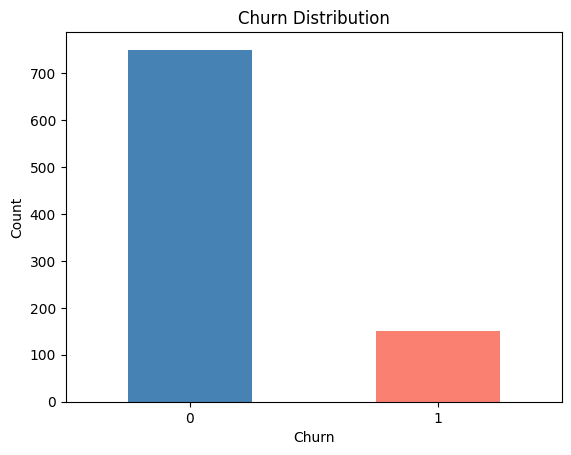

In [65]:
info['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

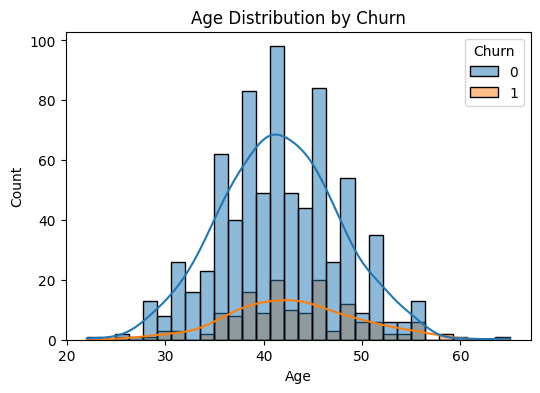

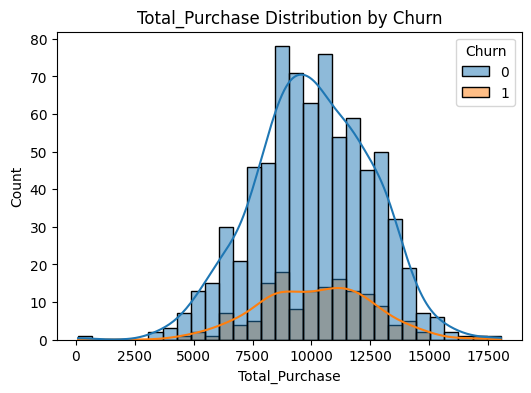

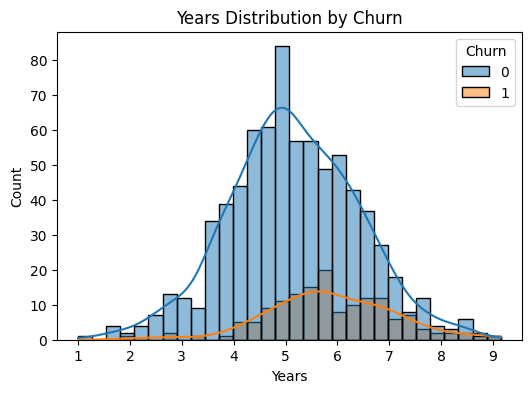

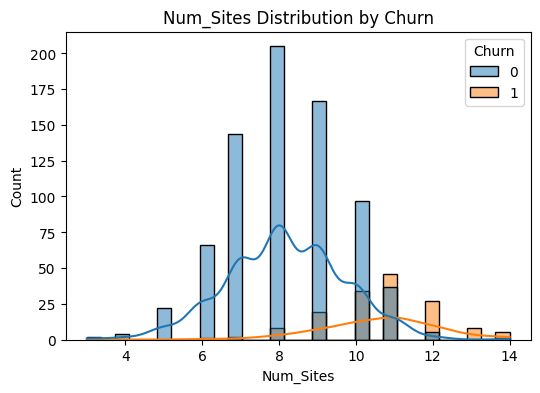

In [66]:
num_cols = ['Age', 'Total_Purchase', 'Years', 'Num_Sites']
cat_cols = ['Account_Manager']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=info, x=col, hue='Churn', bins=30, kde=True)
    plt.title(f'{col} Distribution by Churn')
    plt.show()

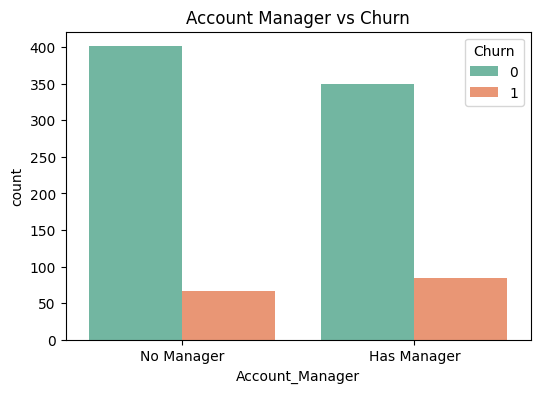

In [67]:

# Account Manager vs Churn
plt.figure(figsize=(6,4))
sns.countplot(data=info, x='Account_Manager', hue='Churn', palette='Set2')
plt.title('Account Manager vs Churn')
plt.xticks(ticks=[0,1], labels=['No Manager', 'Has Manager'])
plt.show()

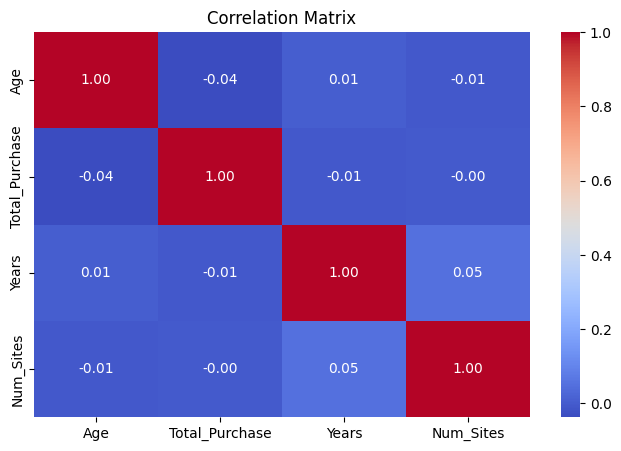

In [68]:
# Correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(info[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

<Axes: >

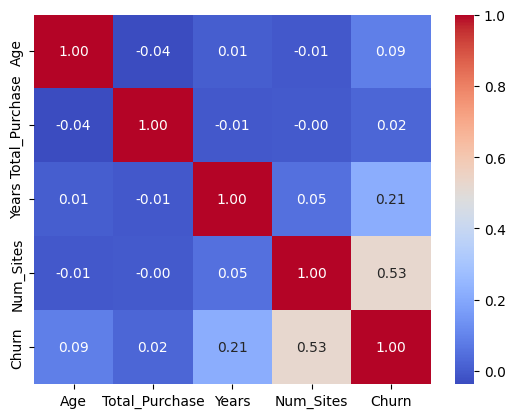

In [69]:
sns.heatmap(info[num_cols + ['Churn']].corr(), annot=True, cmap='coolwarm', fmt='.2f')

In [70]:
info = info.drop(['Names', 'Onboard_date', 'Location', 'Company'], axis=1)

In [71]:
print(info.isnull().sum())
info = info.dropna()

Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Churn              0
dtype: int64


In [72]:
# Define features and target

X = info.drop('Churn', axis=1)
y = info['Churn']

In [73]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
info.dtypes

,0
Age,float64
Total_Purchase,float64
Account_Manager,int64
Years,float64
Num_Sites,float64
Churn,int64


In [75]:
# sigmoid function

def sigmoid(z):
  return 1/(1+np.exp(-z))

In [76]:
# cost function
def costFunction(X, y, theta):
    m = len(y)
    h = sigmoid(X.dot(theta))
    h = np.clip(h, 1e-10, 1 - 1e-10)
    error = (y*np.log(h) + (1-y)*np.log(1-h))
    cost = -1/m * sum(error)
    grad = 1/m * X.T.dot(h-y)
    return cost, grad

In [77]:
# gradient descent
def gradientDescent(X, y, theta, alpha, iterations):
    cost_history = np.zeros(iterations)
    for i in range(iterations):
        cost, grad = costFunction(X, y, theta)
        theta -= alpha * grad
        cost_history[i] = cost
    return theta, cost_history

In [78]:
# predict function

def predict(X, theta):
  return sigmoid(X.dot(theta))


In [79]:
# accuracy function
def accuracy(y_true, y_pred):
 accuracy = np.sum(y_true == y_pred) / len(y_true)
 return accuracy


In [80]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(info.drop('Churn', axis=1), info['Churn'], test_size=0.2, random_state=42)

In [81]:
# feature scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [82]:
# add intercept
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]

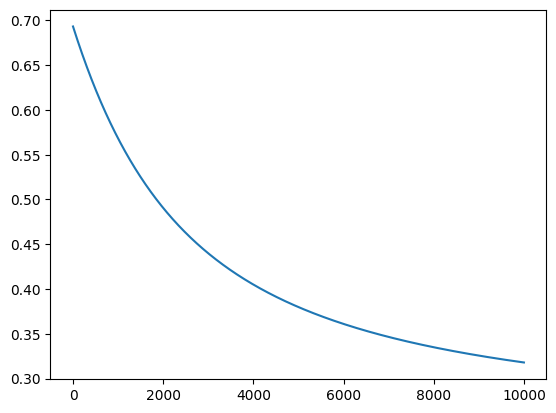

In [83]:
# train model
theta, cost_history = gradientDescent(X_train, y_train, np.zeros(X_train.shape[1]), alpha=0.001, iterations=10000)

plt.plot(range(10000), cost_history)

In [84]:
print("cost_history first 10:", cost_history[:10])
print("cost_history last 10:", cost_history[-10:])
print("Any NaN?", np.isnan(cost_history).any())
print("Any Inf?", np.isinf(cost_history).any())
print("Min:", np.nanmin(cost_history))
print("Max:", np.nanmax(cost_history))

cost_history first 10: [0.69314718 0.69298833 0.69282956 0.69267086 0.69251225 0.69235372
 0.69219527 0.69203689 0.6918786  0.69172039]
cost_history last 10: [0.31808985 0.31808284 0.31807583 0.31806882 0.31806181 0.31805481
 0.3180478  0.3180408  0.3180338  0.31802679]
Any NaN? False
Any Inf? False
Min: 0.31802679395923317
Max: 0.6931471805599453


In [85]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Any NaN in X_train?", np.isnan(X_train).any())
print("Any NaN in y_train?", np.isnan(y_train).any())

X_train shape: (720, 6)
y_train shape: (720,)
Any NaN in X_train? False
Any NaN in y_train? False


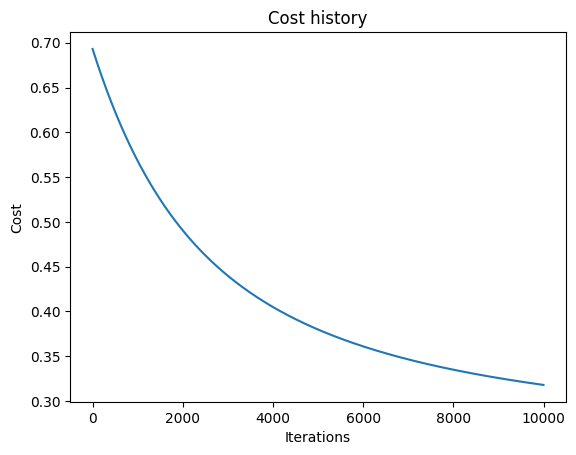

In [86]:
# plot cost history
plt.plot(range(10000), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost history')
plt.show()

In [87]:
print(cost_history[-5:])

[0.31805481 0.3180478  0.3180408  0.3180338  0.31802679]


In [88]:
# predict
y_pred = predict(X_test, theta)
y_pred = [1 if i > 0.5 else 0 for i in y_pred]

In [89]:
# accuracy
accuracy(y_test, y_pred)*100

np.float64(88.88888888888889)

In [90]:
import pandas as pd

new_customers = pd.read_csv('new_customers_1.csv')
new_customers.head()
(new_customers.shape)

(6, 9)

In [91]:
new_customers.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company
0,Andrew Mccall,37.0,9935.53,1,7.71,8.0,2011-08-29 18:37:54,38612 Johnny Stravenue Nataliebury WI 15717-8316,King Ltd
1,Michele Wright,23.0,7526.94,1,9.28,15.0,2013-07-22 18:19:54,"21083 Nicole Junction Suite 332, Youngport ME ...",Cannon-Benson
2,Jeremy Chang,65.0,100.00,1,1.00,15.0,2006-12-11 07:48:13,085 Austin Views Lake Julialand WY 63726-4298,Barron-Robertson
3,Megan Ferguson,32.0,6487.50,0,9.40,14.0,2016-10-28 05:32:13,922 Wright Branch North Cynthialand NC 64721,Sexton-Golden
4,Taylor Young,32.0,13147.71,1,10.00,8.0,2012-03-20 00:36:46,Unit 0789 Box 0734 DPO AP 39702,Wood LLC


In [92]:
new_customers.drop(['Names','Location','Company', 'Onboard_date'],axis=1,inplace=True)

In [93]:
new_customers

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
0,37.0,9935.53,1,7.71,8.0
1,23.0,7526.94,1,9.28,15.0
2,65.0,100.00,1,1.00,15.0
3,32.0,6487.50,0,9.40,14.0
4,32.0,13147.71,1,10.00,8.0
5,22.0,8445.26,1,3.46,14.0


In [94]:
# apply prediction on new data
X_new = scaler.transform(new_customers)
X_new = np.c_[np.ones((X_new.shape[0], 1)), X_new]
y_pred_new = predict(X_new, theta)
y_pred_new = [1 if i > 0.5 else 0 for i in y_pred_new]
y_pred_new

# insert prediction into dataframe
new_customers['Churn'] = y_pred_new
new_customers



,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,37.0,9935.53,1,7.71,8.0,0
1,23.0,7526.94,1,9.28,15.0,1
2,65.0,100.00,1,1.00,15.0,1
3,32.0,6487.50,0,9.40,14.0,1
4,32.0,13147.71,1,10.00,8.0,0
5,22.0,8445.26,1,3.46,14.0,1


              precision    recall  f1-score   support

           0       0.90      0.98      0.94       148
           1       0.83      0.47      0.60        32

    accuracy                           0.89       180
   macro avg       0.86      0.72      0.77       180
weighted avg       0.88      0.89      0.88       180

ROC-AUC Score: 0.7242398648648649


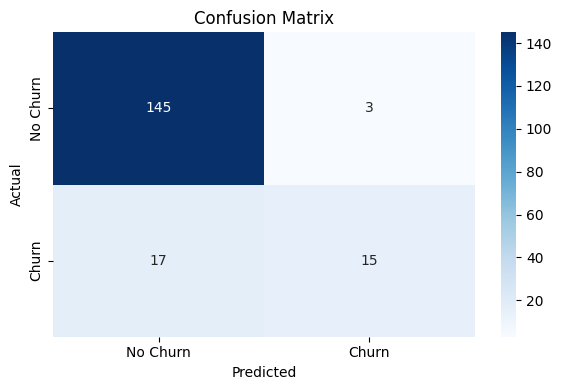

In [95]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Classification report
print(classification_report(y_test, y_pred))

# ROC-AUC
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()